# Fintech Credit Risk Analysis & Loan Default Prediction

## Business Problem

A fintech lending company wants to improve its credit risk management by identifying borrowers who may present a higher risk of loan default.

Loan defaults can result in financial losses, while overly restrictive lending decisions may cause the company to reject potentially profitable customers. The business therefore needs a data-driven approach that balances risk management with lending opportunities.

## Project Objective

This project uses historical loan and borrower data to:

- Analyse borrower and loan characteristics associated with credit risk.
- Identify patterns and factors that may contribute to poor loan performance.
- Develop a machine learning model to estimate borrower default risk.
- Segment borrowers according to predicted risk.
- Translate analytical findings into actionable recommendations for lending and risk-management decisions.

## Business Question

**Which borrower and loan characteristics are associated with higher credit risk, and can historical lending data be used to predict borrowers who are more likely to default?**


In [1]:
# Import libraries for data analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load the raw Lending Club dataset

df = pd.read_csv("../data/raw/loans_full_schema.csv")

## 1. Data Understanding

Before cleaning or modelling the data, the dataset is examined to understand its structure, variables, data types, completeness, and potential data-quality issues.

In [3]:
# Display the first five records
display(df.head())

# Dataset dimensions
print("Number of loans:", df.shape[0])
print("Number of variables:", df.shape[1])

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nDataset Information:")
df.info()

# Missing values
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage (%)": missing_percentage
})

print("\nVariables with Missing Data:")
display(missing_summary[missing_summary["Missing Values"] > 0])

# Duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Numerical summary
print("\nNumerical Variable Summary:")
display(df.describe().T)

,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,2,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,3,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,4,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,5,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


Number of loans: 10000
Number of variables: 56

Column Names:
['Unnamed: 0', 'emp_title', 'emp_length', 'state', 'homeownership', 'annual_income', 'verified_income', 'debt_to_income', 'annual_income_joint', 'verification_income_joint', 'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt', 'loan_purpose', 'appli

,Missing Values,Missing Percentage (%)
verification_income_joint,8545,85.45
annual_income_joint,8505,85.05
debt_to_income_joint,8505,85.05
months_since_90d_late,7715,77.15
months_since_last_delinq,5658,56.58
months_since_last_credit_inquiry,1271,12.71
emp_title,833,8.33
emp_length,817,8.17
num_accounts_120d_past_due,318,3.18
debt_to_income,24,0.24



Duplicate Rows: 0

Numerical Variable Summary:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10000.0,5000.500000,2886.895680,1.00,2500.7500,5000.500,7500.2500,1.000000e+04
emp_length,9183.0,5.930306,3.703734,0.00,2.0000,6.000,10.0000,1.000000e+01
annual_income,10000.0,79222.148412,64734.290492,0.00,45000.0000,65000.000,95000.0000,2.300000e+06
debt_to_income,9976.0,19.308192,15.004851,0.00,11.0575,17.570,25.0025,4.690900e+02
annual_income_joint,1495.0,127914.571244,70168.375404,19200.00,86833.5000,113000.000,151545.5000,1.100000e+06
debt_to_income_joint,1495.0,19.979304,8.054781,0.32,14.1600,19.720,25.5000,3.998000e+01
delinq_2y,10000.0,0.216000,0.683660,0.00,0.0000,0.000,0.0000,1.300000e+01
months_since_last_delinq,4342.0,36.760709,21.634939,1.00,19.0000,34.000,53.0000,1.180000e+02
earliest_credit_line,10000.0,2001.290000,7.795510,1963.00,1997.0000,2003.000,2006.0000,2.015000e+03
inquiries_last_12m,10000.0,1.958200,2.380130,0.00,0.0000,1.000,3.0000,2.900000e+01


## 2. Data Cleaning and Preparation

The dataset contains missing values across several borrower and credit-related variables. Before conducting exploratory analysis and predictive modelling, the data is cleaned to improve consistency and analytical reliability.

Variables with extremely high levels of missing information are removed where they provide limited analytical value. Remaining missing values are handled according to the characteristics and meaning of each variable.

In [4]:
# Create a copy of the original dataset
df_clean = df.copy()

# --------------------------------------------------
# 1. Remove columns with more than 50% missing values
# --------------------------------------------------

missing_pct = df_clean.isnull().mean() * 100

high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

print("Columns removed due to >50% missing data:")
print(high_missing_cols)

df_clean = df_clean.drop(columns=high_missing_cols)


# --------------------------------------------------
# 2. Handle remaining missing numerical values
# --------------------------------------------------

numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())


# --------------------------------------------------
# 3. Handle remaining categorical missing values
# --------------------------------------------------

categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna("Unknown")


# --------------------------------------------------
# 4. Check the cleaned dataset
# --------------------------------------------------

print("\nOriginal dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Columns removed due to >50% missing data:
['annual_income_joint', 'verification_income_joint', 'debt_to_income_joint', 'months_since_last_delinq', 'months_since_90d_late']

Original dataset shape: (10000, 56)
Cleaned dataset shape: (10000, 51)

Remaining missing values:
0

Duplicate rows:
0


C:\Users\Mhela\AppData\Local\Temp\ipykernel_22208\635826930.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include="object").columns


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is conducted to understand the financial and credit characteristics of borrowers and identify patterns that may influence lending risk.

The analysis focuses on loan size, interest rates, borrower income, debt-to-income ratios, loan grades, loan purposes, and other characteristics relevant to credit-risk decision-making.

In [5]:
# Key lending portfolio metrics

print("LOAN PORTFOLIO OVERVIEW")
print("-" * 40)

print(f"Total Loans: {len(df_clean):,}")
print(f"Total Loan Value: ${df_clean['loan_amount'].sum():,.2f}")
print(f"Average Loan Amount: ${df_clean['loan_amount'].mean():,.2f}")
print(f"Median Loan Amount: ${df_clean['loan_amount'].median():,.2f}")
print(f"Average Interest Rate: {df_clean['interest_rate'].mean():.2f}%")
print(f"Average Annual Income: ${df_clean['annual_income'].mean():,.2f}")
print(f"Average Debt-to-Income Ratio: {df_clean['debt_to_income'].mean():.2f}")

LOAN PORTFOLIO OVERVIEW
----------------------------------------
Total Loans: 10,000
Total Loan Value: $163,619,225.00
Average Loan Amount: $16,361.92
Median Loan Amount: $14,500.00
Average Interest Rate: 12.43%
Average Annual Income: $79,222.15
Average Debt-to-Income Ratio: 19.30


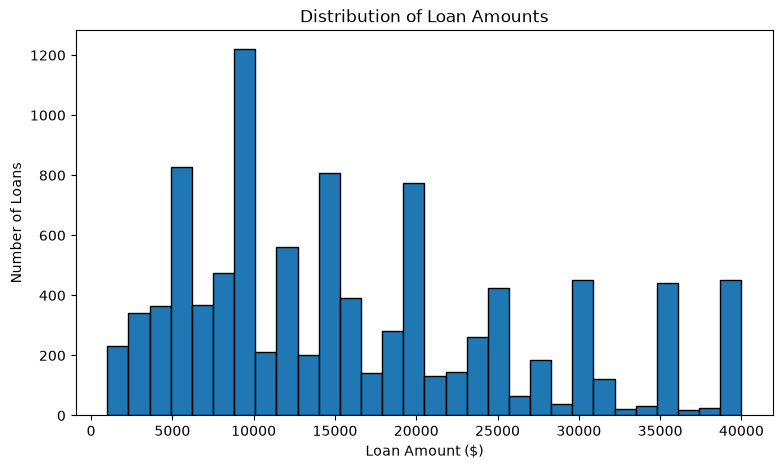

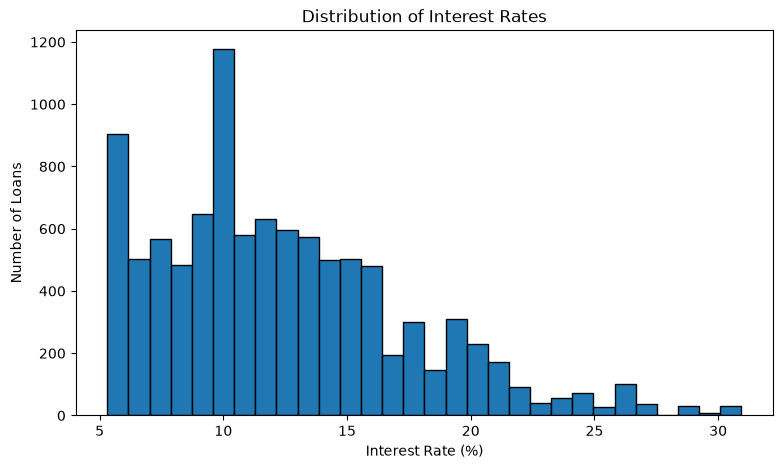

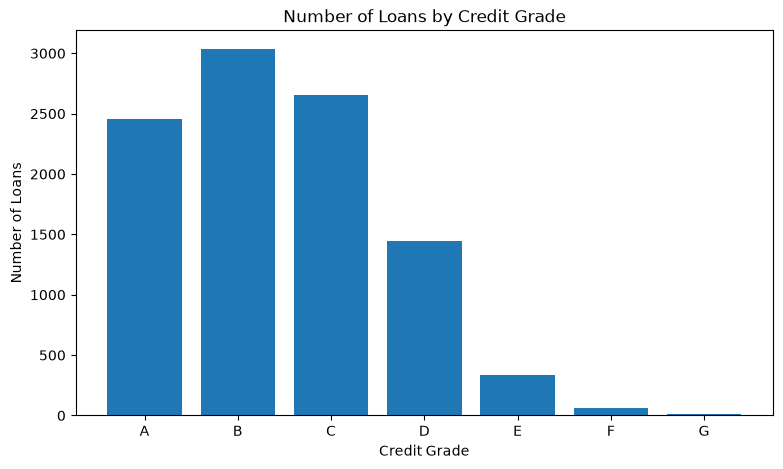

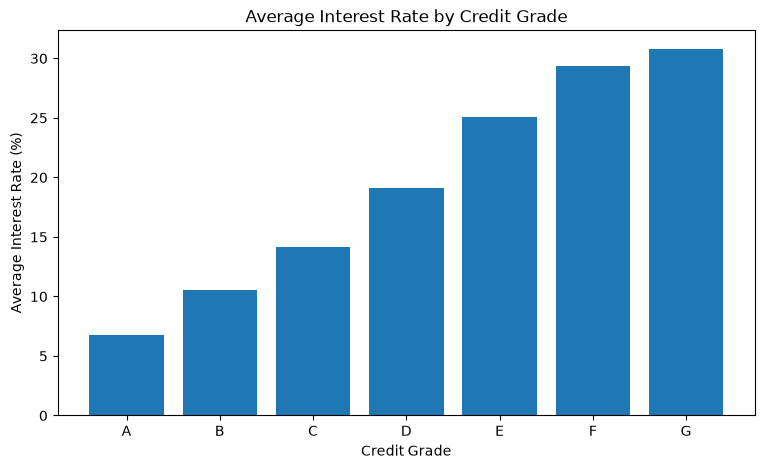

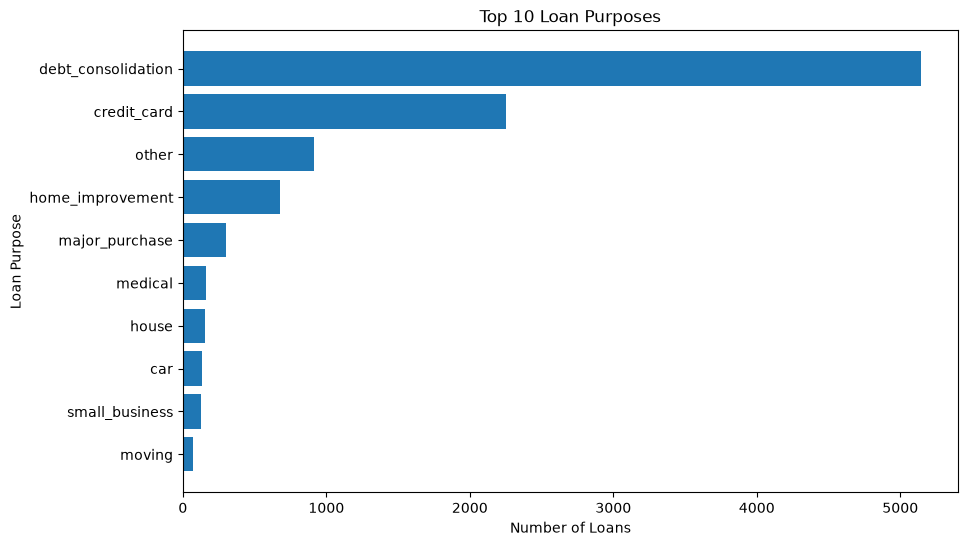

In [6]:
# Distribution of loan amounts

plt.figure(figsize=(9, 5))
plt.hist(df_clean["loan_amount"], bins=30, edgecolor="black")
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount ($)")
plt.ylabel("Number of Loans")
plt.show()


# Distribution of interest rates

plt.figure(figsize=(9, 5))
plt.hist(df_clean["interest_rate"], bins=30, edgecolor="black")
plt.title("Distribution of Interest Rates")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Loans")
plt.show()


# Loan grade distribution

plt.figure(figsize=(9, 5))

grade_counts = df_clean["grade"].value_counts().sort_index()

plt.bar(grade_counts.index, grade_counts.values)
plt.title("Number of Loans by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Number of Loans")
plt.show()


# Average interest rate by credit grade

grade_interest = (
    df_clean.groupby("grade")["interest_rate"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(9, 5))
plt.bar(grade_interest.index, grade_interest.values)
plt.title("Average Interest Rate by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Average Interest Rate (%)")
plt.show()


# Most common loan purposes

purpose_counts = df_clean["loan_purpose"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(purpose_counts.index, purpose_counts.values)
plt.title("Top 10 Loan Purposes")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Purpose")
plt.gca().invert_yaxis()
plt.show()

## 4. Credit Risk Target Definition

To develop a predictive credit-risk model, the loan outcome variable is examined to determine how loan performance should be classified.

The objective is to create a binary target that distinguishes higher-risk/default outcomes from successfully performing loans.

In [7]:
# Examine the loan status variable

print("Loan Status Categories:")
print(df_clean["loan_status"].value_counts())

print("\nLoan Status Percentages:")
print(
    df_clean["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Loan Status Categories:
loan_status
Current               9375
Fully Paid             447
In Grace Period         67
Late (31-120 days)      66
Late (16-30 days)       38
Charged Off              7
Name: count, dtype: int64

Loan Status Percentages:
loan_status
Current               93.75
Fully Paid             4.47
In Grace Period        0.67
Late (31-120 days)     0.66
Late (16-30 days)      0.38
Charged Off            0.07
Name: proportion, dtype: float64
